In [9]:
#Datos sinteticos
#Libreria SDV
#Fecha: 05 junio*
#Autor: yonathan beltran velazquez

In [3]:
import pandas as pd
import numpy as np
import random

In [4]:
import sdv
import sdmetrics

In [7]:
from sdv.metadata import SingleTableMetadata
from sdv.single_table import GaussianCopulaSynthesizer

In [8]:
from sdmetrics.reports.single_table import QualityReport

In [13]:
print("SDV: ", sdv.__version__)
print("SDMetrics: ", sdmetrics.__version__)

SDV:  1.37.0
SDMetrics:  0.28.0


In [16]:
# Crear una tabla de datos REAL como base para la
# generación de Datos Sintéticos.
dfClientes = pd.DataFrame(
    {
        "cliente_id": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
        "edad": [17,18,19,25,32,42,70,28,23,22],
        "ingreso_mensual" : [1800,2000,2500,15000,18000,35000,7000,15000,4000,5000],
        "ciudad": ["Potreo Nuevo", "Atoyac", "Cuichapa", "Córdoba", "Cuitláhuac","Orizaba", "Paraje", "Yanga", "Tierra Blanca", "Calcahualco"],
    }
)

In [17]:
dfClientes

,cliente_id,edad,ingreso_mensual,ciudad
0,1,17,1800,Potreo Nuevo
1,2,18,2000,Atoyac
2,3,19,2500,Cuichapa
3,4,25,15000,Córdoba
4,5,32,18000,Cuitláhuac
5,6,42,35000,Orizaba
6,7,70,7000,Paraje
7,8,28,15000,Yanga
8,9,23,4000,Tierra Blanca
9,10,22,5000,Calcahualco


In [18]:
metadata = SingleTableMetadata()

In [19]:
metadata.detect_from_dataframe(
    data=dfClientes
)

In [20]:
metadata.to_dict()

{'columns': {'cliente_id': {'sdtype': 'id'},
  'edad': {'sdtype': 'numerical'},
  'ingreso_mensual': {'sdtype': 'numerical'},
  'ciudad': {'sdtype': 'categorical'}},
 'METADATA_SPEC_VERSION': 'SINGLE_TABLE_V1',
 'primary_key': 'cliente_id'}

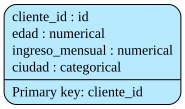

In [22]:
metadata.visualize()

In [25]:
sintetizador = GaussianCopulaSynthesizer(
metadata
)

C:\Users\yonat\anaconda3\Lib\site-packages\sdv\single_table\base.py:182: FutureWarning:

The 'SingleTableMetadata' is deprecated. Please use the new 'Metadata' class for synthesizers.

C:\Users\yonat\anaconda3\Lib\site-packages\sdv\single_table\base.py:138: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.



In [27]:
sintetizador.fit(
    dfClientes
)

In [28]:
dfClientes_falsos = sintetizador.sample(
    num_rows = 200
)

In [29]:
dfClientes_falsos

,cliente_id,edad,ingreso_mensual,ciudad
0,16169768,39,26406,Yanga
1,4918803,19,3899,Tierra Blanca
2,1900081,21,6435,Paraje
3,531516,20,2561,Paraje
4,10211768,37,14802,Tierra Blanca
...,...,...,...,...
195,1577423,18,6122,Córdoba
196,2804584,18,2049,Córdoba
197,10420935,32,9940,Tierra Blanca
198,16659394,20,8773,Tierra Blanca


In [30]:
dfClientes_falsos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   cliente_id       200 non-null    int64 
 1   edad             200 non-null    int64 
 2   ingreso_mensual  200 non-null    int64 
 3   ciudad           200 non-null    object
dtypes: int64(3), object(1)
memory usage: 6.4+ KB


In [31]:
dfClientes.describe()

,cliente_id,edad,ingreso_mensual
count,10.00000,10.000000,10.000000
mean,5.50000,29.600000,10530.000000
std,3.02765,16.063762,10507.568701
min,1.00000,17.000000,1800.000000
25%,3.25000,19.750000,2875.000000
50%,5.50000,24.000000,6000.000000
75%,7.75000,31.000000,15000.000000
max,10.00000,70.000000,35000.000000


In [32]:
dfClientes_falsos.describe()

,cliente_id,edad,ingreso_mensual
count,2.000000e+02,200.000000,200.000000
mean,8.765887e+06,26.055000,10666.595000
std,4.707538e+06,12.567485,9166.867964
min,4.660500e+04,18.000000,2000.000000
25%,5.085226e+06,18.000000,2729.000000
50%,9.212590e+06,20.000000,7975.000000
75%,1.279456e+07,30.000000,16171.250000
max,1.677377e+07,70.000000,35000.000000


In [33]:
#evaluamos la calidad de datos 
#creamos una instancia de QualiyiReport
reporte = QualityReport()

In [35]:
reporte.generate(
    real_data= dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata =metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 178.23it/s]|
Column Shapes Score: 74.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 68.35it/s]|
Column Pair Trends Score: 16.5%

Overall Score (Average): 45.5%



In [36]:
#Evauamo la calidad de los datos 
#creamos uns instanciade qualityReport
reporte= QualityReport()

|Score           | Interpretacion     | 
|----------------|--------------------|
|1               | Identicas|
|0.9             | Muy similar|
|0.7             |Similar|
|0.6             |Diferencias visibles|
|<0.5            |Muy diferentes|

In [40]:
reporte.generate(
    real_data = dfClientes,
    synthetic_data = dfClientes_falsos,
    metadata = metadata.to_dict()
)

Generating report ...

(1/2) Evaluating Column Shapes: |██████████| 4/4 [00:00<00:00, 569.68it/s]|
Column Shapes Score: 74.5%

(2/2) Evaluating Column Pair Trends: |██████████| 6/6 [00:00<00:00, 215.82it/s]|
Column Pair Trends Score: 16.5%

Overall Score (Average): 45.5%

